# Stories

## Deskriptive Statistik

### Setup

In [1]:
import pandas as pd
wide_df = pd.read_csv('../data/2023-12-06-Reviewed-Faces-Per-Image-Wide.csv')

In [2]:
wide_df.head()

,filename,Alice Weidel,Annalena Baerbock,Armin Laschet,Ates Gürpinar,Christian Lindner,Engin Eroglu,Gregor Voht,Jörg Meuthen,Markus Söder,Nicola Beer,Olaf Scholz,Robert Habeck,Saskia Esken,Susanne Hennig-Wellsow
0,abaerbock_13-09-2021_00:00_image0.jpeg,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,abaerbock_13-09-2021_00:00_image1.jpeg,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,abaerbock_13-09-2021_00:00_image2.jpeg,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3,abaerbock_13-09-2021_00:00_image3.jpeg,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,abaerbock_13-09-2021_00:00_image4.jpeg,False,True,False,False,False,False,False,False,False,False,False,False,False,False


In [3]:
count_stories = pd.read_csv('../data/2024-07-04-Stories-Count-Annotation-Not-Sampled-GPT4o-V3-TEST.csv')

In [4]:
count_stories.head()

,GPT Count,GPT Crowd,Image,Unnamed: 0
0,1,False,abaerbock_13-09-2021_00:00_image0.jpeg,NaN
1,1,False,abaerbock_13-09-2021_00:00_image2.jpeg,NaN
2,1,False,abaerbock_13-09-2021_00:00_image3.jpeg,NaN
3,1,False,abaerbock_13-09-2021_00:00_image4.jpeg,NaN
4,1,False,abaerbock_13-09-2021_00:00_image5.jpeg,NaN


In [5]:
count_stories.rename(columns={"Image": "filename"}, inplace=True)

In [6]:
# Function to concatenate the names with True values
def concatenate_true_names(row):
    names = [col for col in wide_df.columns if row[col] == True]
    return list(names)

# Apply the function to each row and create a new column
wide_df['Names'] = wide_df.apply(concatenate_true_names, axis=1)

In [7]:
# Merge wide_df mit metadaten.
metadata_df = pd.read_csv('../data/2023-11-02-story-metadata.csv')

In [8]:
users_df = pd.read_csv("../data/2022-10-10-users.csv", sep=";")

In [9]:
users_df = users_df.rename(columns={'id': 'user_id'})

In [10]:
faces_master_df = pd.merge(wide_df[['filename', 'Names']], metadata_df[['username', 'taken_at_utc', 'filename']], on="filename", how="right")

In [11]:
faces_master_df['Names'] = faces_master_df['Names'].apply(lambda x: ["None"] if x is None or x != x else x)

In [12]:
faces_master_df = pd.merge(faces_master_df[['filename', 'Names', 'username', 'taken_at_utc']], users_df, on="username", how="left")

In [13]:
len(faces_master_df)

2209

In [14]:
party_affiliation_names = {
  "CDU": ["Armin Laschet"],
  "CSU": ["Markus Söder"],
  "SPD": ["Olaf Scholz"],
 # "AfD": ["Alice Weidel", "Jörg Meuthen"],
  "FDP": ["Christian Lindner"],
  "B90DieGruenen": ["Annalena Baerbock"],
 # "FW": ["Gregor Voht", "Engin Eroglu"],
 # "Linke": ["Susanne Hennig-Wellsow", "Ates Gürpinar"],
}

In [15]:
selected_accounts = ['armin_laschet', 'abaerbock', 'christlichsozialeunion',
       'christianlindner', 'cdu', 'fdp', 'die_gruenen', 'markus.soeder',
       'spdde', 'olafscholz']

In [16]:
selected_parties = ["CDU", "CSU", "SPD", "FDP", "B90DieGruenen"]
faces_master_df = faces_master_df[faces_master_df['party'].isin(selected_parties)].copy()
faces_master_df = faces_master_df[faces_master_df['username'].isin(selected_accounts)].copy()

In [17]:
len(faces_master_df)

1424

In [18]:
def filter_names(row):
    party = row['party']
    names = row['Names']
    valid_names = party_affiliation_names.get(party, [])
    valid_names.append("None")
    filtered_names = [name for name in names if name in valid_names]
    if len(filtered_names) == 0:
      return "None"

    elif len(filtered_names) == 1:
      return filtered_names[0]

    else:
      return "Error"


# Apply the function to each row
faces_master_df['Names'] = faces_master_df.apply(filter_names, axis=1)

In [19]:
faces_master_df.head()

,filename,Names,username,taken_at_utc,user_id,party,type
0,armin_laschet_14-09-2021_00:00_video0.jpeg,Armin Laschet,armin_laschet,2021-09-13 08:56:01,4852192933,CDU,Person
1,abaerbock_14-09-2021_00:00_image0.jpeg,None,abaerbock,2021-09-13 16:14:23,7012133944,B90DieGruenen,Person
2,christlichsozialeunion_14-09-2021_00:00_video0...,None,christlichsozialeunion,2021-09-13 08:43:48,1573431041,CSU,Party
4,christianlindner_14-09-2021_00:00_image0.jpeg,Christian Lindner,christianlindner,2021-09-13 07:31:38,2927737384,FDP,Person
6,cdu_14-09-2021_00:00_video0.jpeg,None,cdu,2021-09-13 13:33:18,1558377791,CDU,Party


In [20]:
faces_master_df['username'].unique()

array(['armin_laschet', 'abaerbock', 'christlichsozialeunion',
       'christianlindner', 'cdu', 'fdp', 'die_gruenen', 'spdde',
       'markus.soeder', 'olafscholz'], dtype=object)

In [21]:
final_count_df = pd.merge(count_stories[['GPT Count', 'filename']], faces_master_df, on="filename", how="right")

In [22]:
########### HIER WEITERMACHEN!!!
##### HIER Muss ich am besten GPT Count NaN setzen, dann sollte der Code klappen

import numpy as np

# Function to check if a set contains the string 'None'
def contains_none_string(row):
    # Check if 'None' is in the set
    if 'None' in row['Names']:
      return np.NaN
    else:
      return row['GPT Count']

# Apply the function to each element in the column
final_count_df['GPT Count'] = final_count_df.apply(contains_none_string, axis=1)

In [23]:
final_count_df.head()

,GPT Count,filename,Names,username,taken_at_utc,user_id,party,type
0,3+,armin_laschet_14-09-2021_00:00_video0.jpeg,Armin Laschet,armin_laschet,2021-09-13 08:56:01,4852192933,CDU,Person
1,NaN,abaerbock_14-09-2021_00:00_image0.jpeg,None,abaerbock,2021-09-13 16:14:23,7012133944,B90DieGruenen,Person
2,NaN,christlichsozialeunion_14-09-2021_00:00_video0...,None,christlichsozialeunion,2021-09-13 08:43:48,1573431041,CSU,Party
3,3+,christianlindner_14-09-2021_00:00_image0.jpeg,Christian Lindner,christianlindner,2021-09-13 07:31:38,2927737384,FDP,Person
4,NaN,cdu_14-09-2021_00:00_video0.jpeg,None,cdu,2021-09-13 13:33:18,1558377791,CDU,Party


### Kandidaten

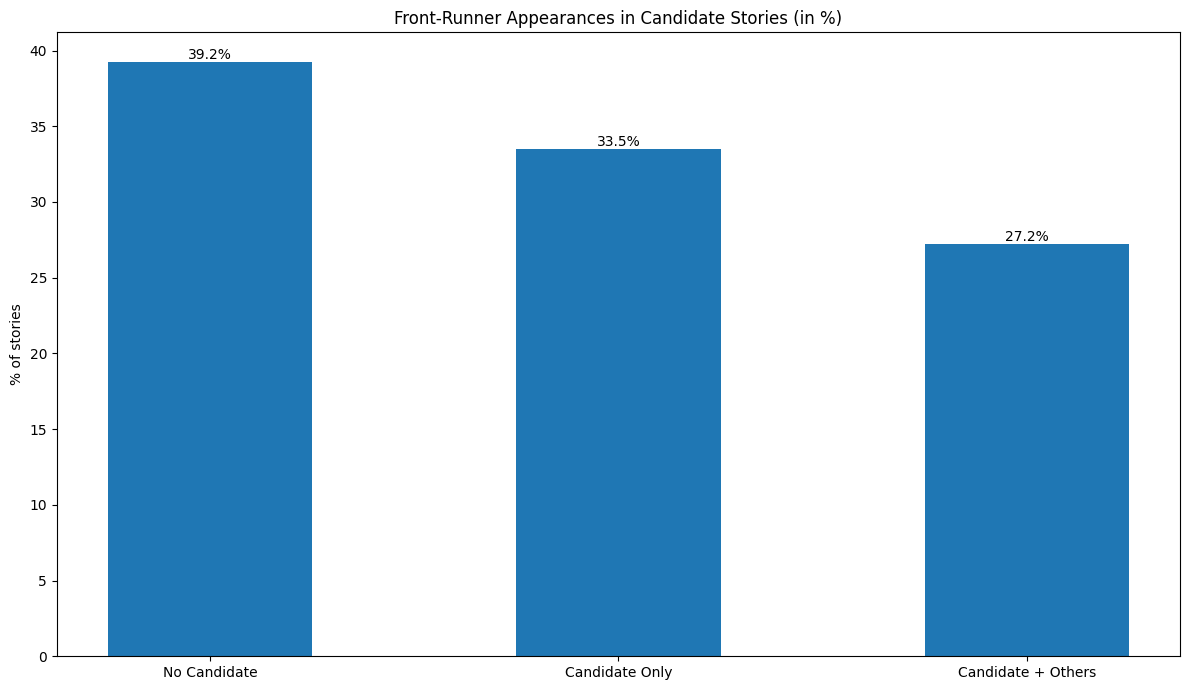

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, entity_type):
    # Filter DataFrame for the specified entity type
    df_filtered = df[df['type'] == entity_type]

    # Calculate counts based on conditions
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }

    # Calculate percentages
    total = sum(counts.values())
    percentages_dict = {label: (count / total * 100) if total > 0 else 0 for label, count in counts.items()}

    return percentages_dict

# Example DataFrame (replace final_count_df with your actual DataFrame)
# final_count_df = pd.read_csv('path_to_your_data.csv')

# Get percentages for 'Person' type
percentages_dict = get_lengths_and_labels(final_count_df, "Person")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar positions and width
bar_width = 0.5
positions = range(len(percentages_dict))

# Plotting the bars
bars = ax.bar(positions, percentages_dict.values(), bar_width)

# Add percentage labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

# Set labels and title
ax.set_ylabel('% of stories')
ax.set_title('Front-Runner Appearances in Candidate Stories (in %)')
ax.set_xticks(positions)
ax.set_xticklabels(percentages_dict.keys())

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()

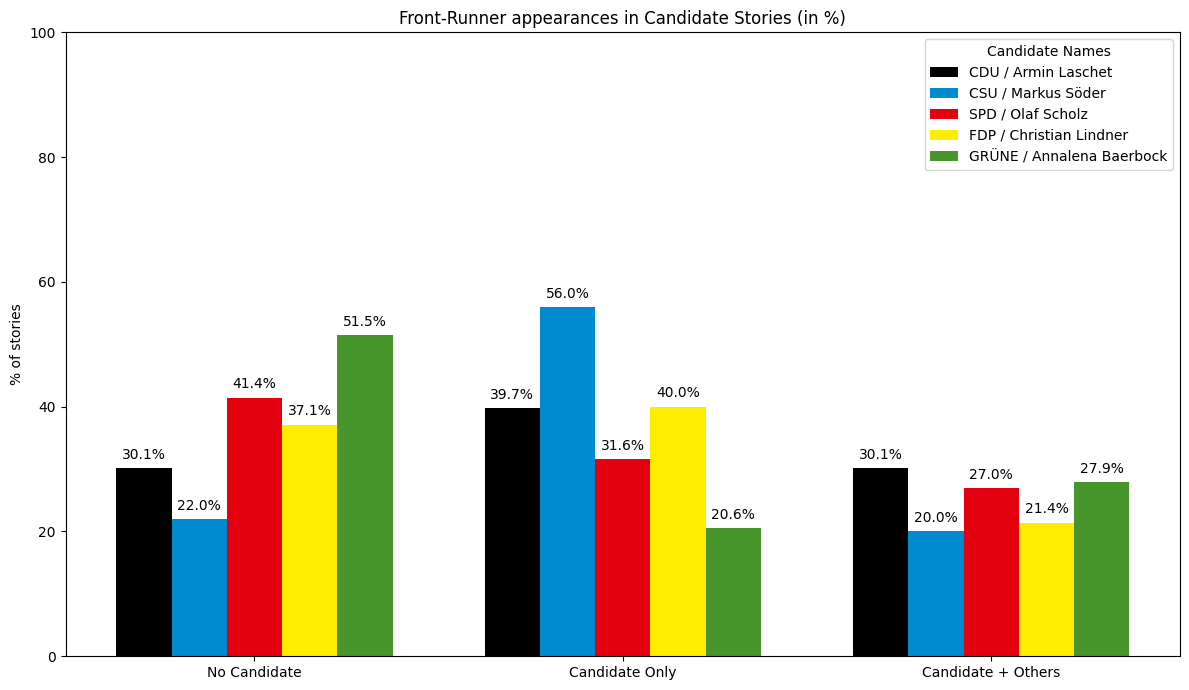

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Static dictionary for candidate-to-party mapping
party_affiliation_names = {
    "CDU": ["CDU / Armin Laschet"],
    "CSU": ["CSU / Markus Söder"],
    "SPD": ["SPD / Olaf Scholz"],
    "FDP": ["FDP / Christian Lindner"],
    "B90DieGruenen": ["GRÜNE / Annalena Baerbock"],
}

# Typical party colors
party_colors = {
    "CDU": "#000000",
    "CSU": "#008ACF",
    "SPD": "#E3000F",
    "FDP": "#FFED00",
    "B90DieGruenen": "#46962B",
}

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, entity_type):
    # Filter DataFrame for the specified entity type
    df_filtered = df[df['type'] == entity_type]

    # Define the conditions
    def apply_conditions(df):
        return {
            'No Candidate': len(df[(df['Names'] == "None")]),
            'Candidate Only': len(df[(df['Names'] != "None") & (df['GPT Count'] == "1")]),
            'Candidate + Others': len(df[(df['Names'] != "None") & (df['GPT Count'] != "0") & (df['GPT Count'] != "1")])
        }

    percentages_dict = {label: [] for label in ['No Candidate', 'Candidate Only', 'Candidate + Others']}
    parties = list(party_affiliation_names.keys())

    # Iterate over each party and apply conditions
    for party in parties:
        party_df = df_filtered[df_filtered['party'] == party]
        total_count = len(party_df)  # Total rows for this party

        # Apply conditions directly to the filtered party_df
        condition_counts = apply_conditions(party_df)

        for label, count in condition_counts.items():
            percentage = (count / total_count) * 100 if total_count > 0 else 0
            percentages_dict[label].append(percentage)

    return percentages_dict, parties

# Get percentages and parties
percentages_dict, parties = get_lengths_and_labels(final_count_df, "Person")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar positions and width
bar_width = 0.15
positions = range(len(percentages_dict.keys()))

# Plot bars for each party
for i, party in enumerate(parties):
    candidate_name = party_affiliation_names[party][0]  # Assume one candidate per party for simplicity
    percentages = [percentages_dict[label][i] for label in percentages_dict.keys()]
    ax.bar([p + i * bar_width for p in positions], percentages, bar_width, label=candidate_name, color=party_colors[party])

# Set labels and title
ax.set_ylabel('% of stories')
#ax.set_ylabel('Percentage of Rows')
ax.set_title('Front-Runner appearances in Candidate Stories (in %)')
ax.set_xticks([p + bar_width * (len(parties) - 1) / 2 for p in positions])  # Center x-tick labels
ax.set_xticklabels(percentages_dict.keys())
ax.legend(title='Candidate Names')

# Force y-axis to range from 0 to 100
ax.set_ylim(0, 100)

# Adding labels on top of bars
for i, party in enumerate(parties):
    for j, label in enumerate(percentages_dict.keys()):
        percentage = percentages_dict[label][i]
        ax.text(j + i * bar_width, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom')

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()

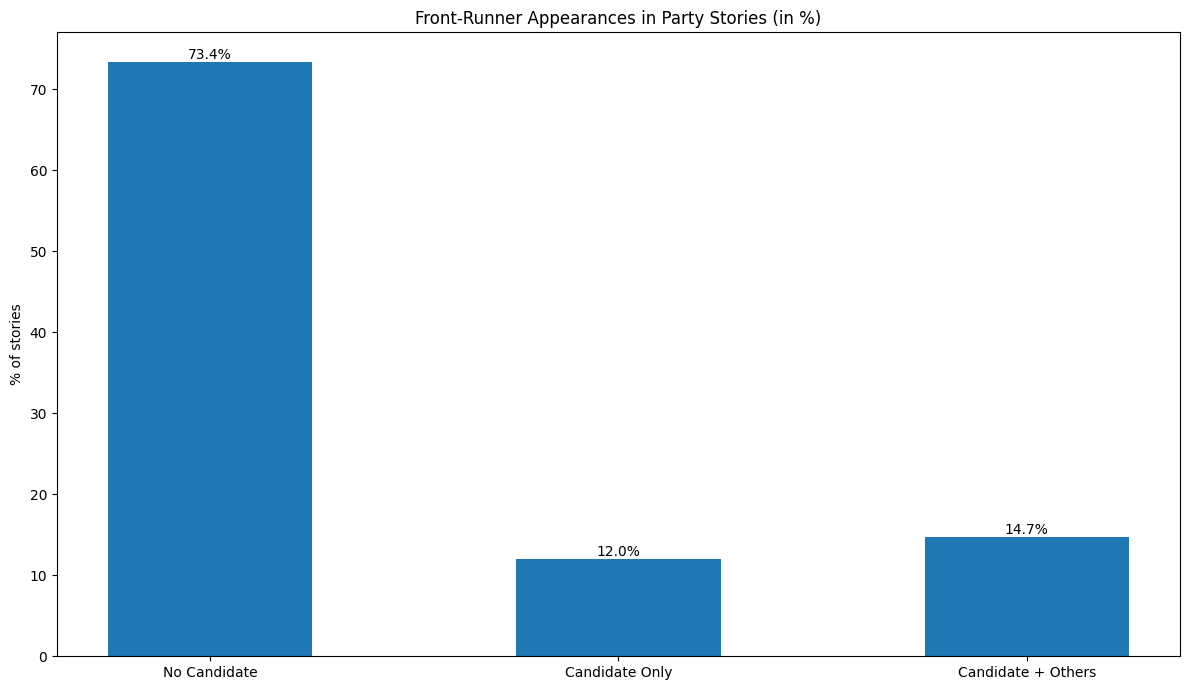

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, entity_type):
    # Filter DataFrame for the specified entity type
    df_filtered = df[df['type'] == entity_type]

    # Calculate counts based on conditions
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }

    # Calculate percentages
    total = sum(counts.values())
    percentages_dict = {label: (count / total * 100) if total > 0 else 0 for label, count in counts.items()}

    return percentages_dict

# Example DataFrame (replace final_count_df with your actual DataFrame)
# final_count_df = pd.read_csv('path_to_your_data.csv')

# Get percentages for 'Person' type
percentages_dict = get_lengths_and_labels(final_count_df, "Party")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar positions and width
bar_width = 0.5
positions = range(len(percentages_dict))

# Plotting the bars
bars = ax.bar(positions, percentages_dict.values(), bar_width)

# Add percentage labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

# Set labels and title
ax.set_ylabel('% of stories')
ax.set_title('Front-Runner Appearances in Party Stories (in %)')
ax.set_xticks(positions)
ax.set_xticklabels(percentages_dict.keys())

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()

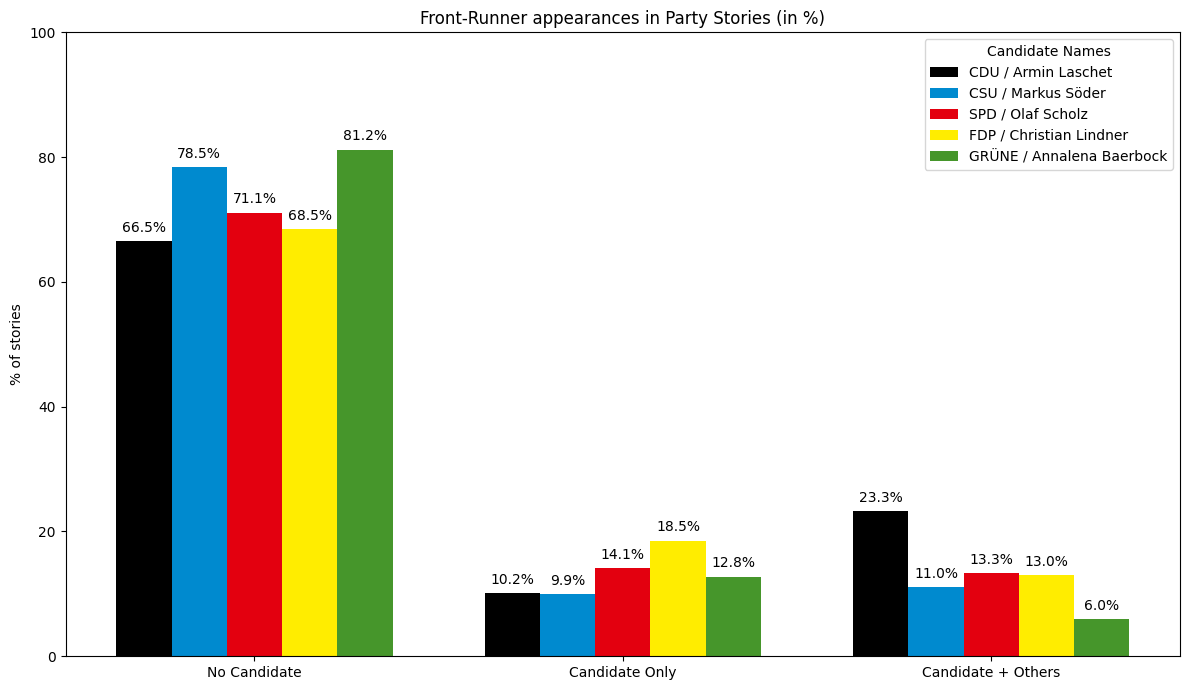

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Static dictionary for candidate-to-party mapping
party_affiliation_names = {
    "CDU": ["CDU / Armin Laschet"],
    "CSU": ["CSU / Markus Söder"],
    "SPD": ["SPD / Olaf Scholz"],
    "FDP": ["FDP / Christian Lindner"],
    "B90DieGruenen": ["GRÜNE / Annalena Baerbock"],
}

# Typical party colors
party_colors = {
    "CDU": "#000000",
    "CSU": "#008ACF",
    "SPD": "#E3000F",
    "FDP": "#FFED00",
    "B90DieGruenen": "#46962B",
}

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, entity_type):
    # Filter DataFrame for the specified entity type
    df_filtered = df[df['type'] == entity_type]

    # Define the conditions
    def apply_conditions(df):
        return {
            'No Candidate': len(df[(df['Names'] == "None")]),
            'Candidate Only': len(df[(df['Names'] != "None") & (df['GPT Count'] == "1")]),
            'Candidate + Others': len(df[(df['Names'] != "None") & (df['GPT Count'] != "0") & (df['GPT Count'] != "1")])
        }

    percentages_dict = {label: [] for label in ['No Candidate', 'Candidate Only', 'Candidate + Others']}
    parties = list(party_affiliation_names.keys())

    # Iterate over each party and apply conditions
    for party in parties:
        party_df = df_filtered[df_filtered['party'] == party]
        total_count = len(party_df)  # Total rows for this party

        # Apply conditions directly to the filtered party_df
        condition_counts = apply_conditions(party_df)

        for label, count in condition_counts.items():
            percentage = (count / total_count) * 100 if total_count > 0 else 0
            percentages_dict[label].append(percentage)

    return percentages_dict, parties

# Get percentages and parties
percentages_dict, parties = get_lengths_and_labels(final_count_df, "Party")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define bar positions and width
bar_width = 0.15
positions = range(len(percentages_dict.keys()))

# Plot bars for each party
for i, party in enumerate(parties):
    candidate_name = party_affiliation_names[party][0]  # Assume one candidate per party for simplicity
    percentages = [percentages_dict[label][i] for label in percentages_dict.keys()]
    ax.bar([p + i * bar_width for p in positions], percentages, bar_width, label=candidate_name, color=party_colors[party])

# Set labels and title
ax.set_ylabel('% of stories')
#ax.set_ylabel('Percentage of Rows')
ax.set_title('Front-Runner appearances in Party Stories (in %)')
ax.set_xticks([p + bar_width * (len(parties) - 1) / 2 for p in positions])  # Center x-tick labels
ax.set_xticklabels(percentages_dict.keys())
ax.legend(title='Candidate Names')

# Force y-axis to range from 0 to 100
ax.set_ylim(0, 100)

# Adding labels on top of bars
for i, party in enumerate(parties):
    for j, label in enumerate(percentages_dict.keys()):
        percentage = percentages_dict[label][i]
        ax.text(j + i * bar_width, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom')

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()

## Statistische Analyse

### Unterschiede

### RQ2a: Front Runner vs Party

There is a significant difference in the distribution of front-runner appearances ('No Candidate,' 'Candidate Only,' and 'Candidate + Others') between Instagram posts tagged as 'Party' and those tagged as 'Person.'

Chi-squared: 173.23643115331458, p-value: 2.410942999612685e-38, Cramér's V: 0.349
Significance level: ***


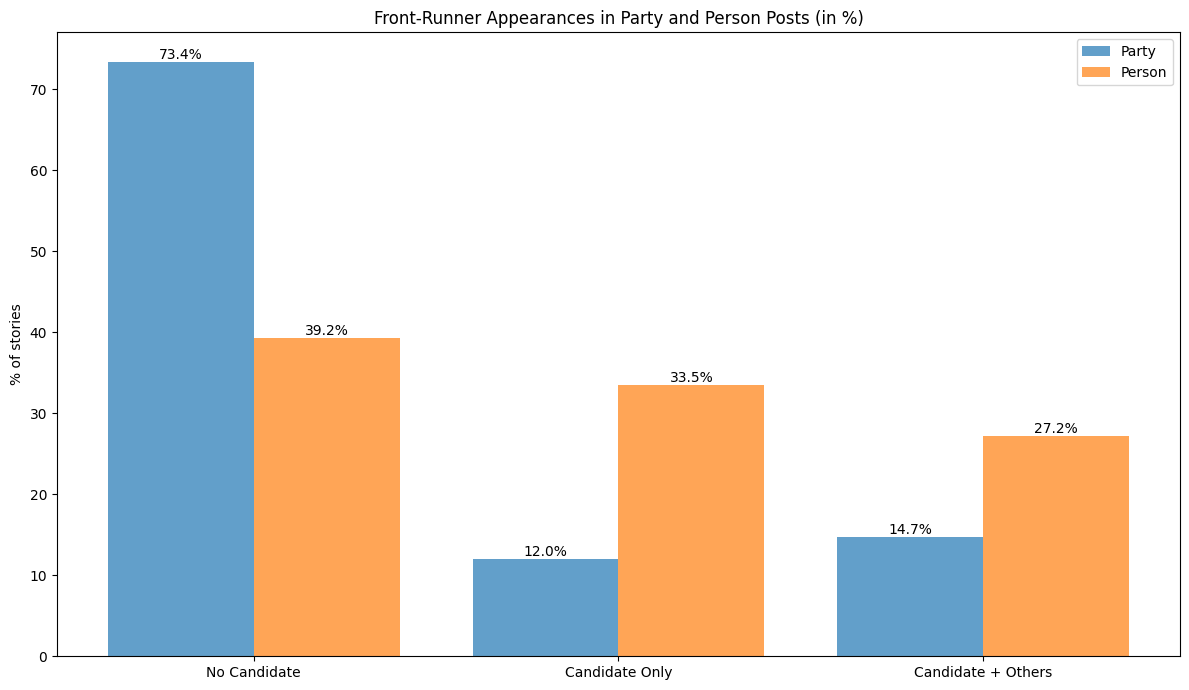

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, entity_type):
    df_filtered = df[df['type'] == entity_type]
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }
    total = sum(counts.values())
    percentages_dict = {label: (count / total * 100) if total > 0 else 0 for label, count in counts.items()}
    return counts, percentages_dict

# Get counts for 'Party' type
party_counts, party_percentages = get_lengths_and_labels(final_count_df, "Party")
# Get counts for 'Person' type
person_counts, person_percentages = get_lengths_and_labels(final_count_df, "Person")

# Create contingency table
contingency_table = pd.DataFrame({
    'No Candidate': [party_counts['No Candidate'], person_counts['No Candidate']],
    'Candidate Only': [party_counts['Candidate Only'], person_counts['Candidate Only']],
    'Candidate + Others': [party_counts['Candidate + Others'], person_counts['Candidate + Others']]
}, index=['Party', 'Person'])

# Perform Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramér's V
n = contingency_table.values.sum()
phi2 = chi2 / n
r, k = contingency_table.shape
cramers_v = np.sqrt(phi2 / min(k-1, r-1))

# Print the results
print(f"Chi-squared: {chi2}, p-value: {p}, Cramér's V: {cramers_v:.3f}")

# Determine significance level
if p < 0.001:
    significance = "***"
elif p < 0.01:
    significance = "**"
elif p < 0.05:
    significance = "*"
else:
    significance = "ns"  # not significant

print(f"Significance level: {significance}")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))
positions = range(len(party_percentages))

# Plotting the bars for Party
bars_party = ax.bar(positions, party_percentages.values(), width=0.4, label='Party', alpha=0.7)
# Plotting the bars for Person with offset
bars_person = ax.bar([p + 0.4 for p in positions], person_percentages.values(), width=0.4, label='Person', alpha=0.7)

# Add percentage labels on top of the bars
for bar in bars_party + bars_person:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

# Set labels and title
ax.set_ylabel('% of stories')
ax.set_title('Front-Runner Appearances in Party and Person Posts (in %)')
ax.set_xticks([p + 0.2 for p in positions])
ax.set_xticklabels(party_percentages.keys())
ax.legend()

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()

In [ ]:
contingency_table

,No Candidate,Candidate Only,Candidate + Others
Party,540,88,108
Person,268,229,186


### RQ2a: Frunter Runner vs Party per Party

*UPDATED*: Between Parties


For each party within each account type (Party accounts and Person accounts), the hypotheses tested are:

Null Hypothesis (H₀):
Statement: The distribution of Instagram campaign strategies used by this party is the same as the overall distribution of strategies across all parties within the same account type.

Alternative Hypothesis (H₁):
Statement: The distribution of Instagram campaign strategies used by this party is different from the overall distribution of strategies across all parties within the same account type.

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
from statsmodels.stats.multitest import multipletests

# Function to calculate counts for each category per party
def get_party_counts(df, party):
    df_filtered = df[df['party'] == party]
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }
    return counts

# Function to perform Chi-squared tests for a given dataframe
def perform_chi_squared_tests(df, group_name):
    # Unique parties in the dataset
    parties = df['party'].unique()

    # Create a contingency table
    contingency_table = pd.DataFrame(index=parties, columns=['No Candidate', 'Candidate Only', 'Candidate + Others']).fillna(0)

    # Fill the contingency table with counts
    for party in parties:
        counts = get_party_counts(df, party)
        contingency_table.loc[party] = [counts['No Candidate'], counts['Candidate Only'], counts['Candidate + Others']]

    # Calculate the total counts for each category across all parties
    overall_counts = contingency_table.sum(axis=0)

    # Initialize results storage
    chi2_results_list = []
    p_values = []  # List to store p-values for multiple testing correction

    # Loop through each party and perform Chi-squared test against overall counts
    for party in parties:
        # Prepare the observed counts for the current party
        observed = contingency_table.loc[party].astype(int).values
        expected = overall_counts.values.astype(float) * (observed.sum() / overall_counts.sum())

        # Perform Chi-squared test
        chi2, p, dof, expected_freqs = chi2_contingency([observed, expected])
        p_values.append(p)  # Store the raw p-value

        # Check if chi-squared test requirements are met
        meets_requirements = np.all(expected_freqs >= 5)

        # Calculate Cramér's V
        n = observed.sum()  # Total number of observations for the party
        r, k = 2, len(observed)  # Rows and columns in the contingency table
        cramers_v = np.sqrt(chi2 / (n * (min(k - 1, r - 1) or 1)))

        # Store initial results without significance label
        chi2_results_list.append({
            'Party': party,
            'Chi-squared': chi2,
            'Raw p-value': p,
            'Cramér\'s V': cramers_v,
            'Meets Chi-squared Requirements': "Yes" if meets_requirements else "No"
        })

    # Apply Bonferroni correction to p-values
    p_values = np.array(p_values)
    corrected_p_values = multipletests(p_values, method='bonferroni')[1]

    # Update results with corrected p-values and significance labels
    for i, result in enumerate(chi2_results_list):
        corrected_p = corrected_p_values[i]
        result['Corrected p-value'] = corrected_p

        # Determine significance level after correction
        if corrected_p < 0.001:
            significance_label = "***"
        elif corrected_p < 0.01:
            significance_label = "**"
        elif corrected_p < 0.05:
            significance_label = "*"
        else:
            significance_label = "ns"
        result['Significant'] = significance_label

    # Convert the results list to a DataFrame
    chi2_results_df = pd.DataFrame(chi2_results_list)

    return chi2_results_df, contingency_table

# Assuming 'account_type' is the column indicating 'Party' or 'Person' accounts
# Split the dataset into Party accounts and Person accounts
df_party_accounts = final_count_df[final_count_df['type'] == 'Party']
df_person_accounts = final_count_df[final_count_df['type'] == 'Person']

# Perform the analysis for Party accounts
chi2_results_party, contingency_table_party = perform_chi_squared_tests(df_party_accounts, "Party")

# Perform the analysis for Person accounts
chi2_results_person, contingency_table_person = perform_chi_squared_tests(df_person_accounts, "Person")


In [ ]:
print(chi2_results_party.to_markdown())

|    | Party         |   Chi-squared |   Raw p-value |   Cramér's V | Meets Chi-squared Requirements   |   Corrected p-value | Significant   |
|---:|:--------------|--------------:|--------------:|-------------:|:---------------------------------|--------------------:|:--------------|
|  0 | CSU           |      1.56006  |     0.458392  |    0.0930968 | Yes                              |            1        | ns            |
|  1 | CDU           |      5.76006  |     0.056133  |    0.156228  | Yes                              |            0.280665 | ns            |
|  2 | FDP           |      0.909753 |     0.634526  |    0.129797  | Yes                              |            1        | ns            |
|  3 | B90DieGruenen |      5.3845   |     0.0677284 |    0.201209  | Yes                              |            0.338642 | ns            |
|  4 | SPD           |      0.34916  |     0.839809  |    0.0512374 | Yes                              |            1        | ns            |

In [ ]:
print(chi2_results_person.to_markdown())

|    | Party         |   Chi-squared |   Raw p-value |   Cramér's V | Meets Chi-squared Requirements   |   Corrected p-value | Significant   |
|---:|:--------------|--------------:|--------------:|-------------:|:---------------------------------|--------------------:|:--------------|
|  0 | CDU           |      3.89182  |     0.142858  |    0.136459  | Yes                              |           0.714288  | ns            |
|  1 | B90DieGruenen |      9.69573  |     0.0078451 |    0.218009  | Yes                              |           0.0392255 | *             |
|  2 | FDP           |      0.90991  |     0.634476  |    0.114835  | Yes                              |           1         | ns            |
|  3 | CSU           |      5.73172  |     0.0569341 |    0.342015  | Yes                              |           0.28467   | ns            |
|  4 | SPD           |      0.182522 |     0.91278   |    0.0346526 | Yes                              |           1         | ns            |

In [ ]:
from statsmodels.stats.multitest import multipletests

parties = final_count_df['party'].unique()

# Function to calculate counts for a given party and account type
def get_party_account_counts(df, party):
    # Filter for the current party
    df_filtered = df[df['party'] == party]

    # Define conditions for different categories
    conditions = {
        'No Candidate': (df_filtered['Names'] == "None"),
        'Candidate Only': (df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1"),
        'Candidate + Others': (df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")
    }

    # Count the number of occurrences for each category and account type
    counts = {
        key: {
            'Person': len(df_filtered[condition & (df_filtered['type'] == "Person")]),
            'Party': len(df_filtered[condition & (df_filtered['type'] == "Party")])
        }
        for key, condition in conditions.items()
    }

    return counts

# Initialize the results storage
chi2_results_list = []
p_values = []

# Loop through each party to calculate the chi-squared statistic for each
for party in parties:
    # Get counts for the current party
    counts = get_party_account_counts(final_count_df, party)

    # Create a contingency table for the chi-squared test
    contingency_table_party = pd.DataFrame([
        [counts['No Candidate']['Person'], counts['Candidate Only']['Person'], counts['Candidate + Others']['Person']],
        [counts['No Candidate']['Party'], counts['Candidate Only']['Party'], counts['Candidate + Others']['Party']]
    ], columns=['No Candidate', 'Candidate Only', 'Candidate + Others'], index=['Person', 'Party'])

    # Perform the chi-squared test
    chi2, p, dof, expected = chi2_contingency(contingency_table_party)

    # Check chi-squared test requirements
    meets_requirements = np.all(expected >= 5)

    # Calculate Cramér's V
    n = contingency_table_party.values.sum()  # Total number of observations
    r, k = contingency_table_party.shape  # Number of rows and columns
    min_dim = min(k - 1, r - 1)
    if min_dim > 0:
        cramers_v = np.sqrt(chi2 / (n * min_dim))
    else:
        cramers_v = np.nan  # Handle division by zero if min_dim is zero

    p_values.append(p)

    # Append the results to the list without 'Significant' and 'Corrected p-value' for now
    chi2_results_list.append({
        'Party': party,
        'Chi2 Statistic': chi2,
        'p-value': p,
        'Cramér\'s V': cramers_v,
        'Meets Chi-squared Requirements': "Yes" if meets_requirements else "No"
    })

# Adjust the p-values using the Bonferroni correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# Update the chi2_results_list with the corrected p-values and significance labels
for i in range(len(chi2_results_list)):
    corrected_p = pvals_corrected[i]
    significance_label = ""
    if corrected_p < 0.001:
        significance_label = "***"
    elif corrected_p < 0.01:
        significance_label = "**"
    elif corrected_p < 0.05:
        significance_label = "*"
    else:
        significance_label = "ns"

    # Update the existing entries in chi2_results_list
    chi2_results_list[i]['Corrected p-value'] = corrected_p
    chi2_results_list[i]['Significant'] = significance_label

# Convert the list to a DataFrame
chi2_results_df = pd.DataFrame(chi2_results_list)


In [ ]:
print(chi2_results_df.to_markdown())

|    | Party         |   Chi2 Statistic |     p-value |   Cramér's V | Meets Chi-squared Requirements   |   Corrected p-value | Significant   |
|---:|:--------------|-----------------:|------------:|-------------:|:---------------------------------|--------------------:|:--------------|
|  0 | CDU           |          71.8651 | 2.4814e-16  |     0.401864 | Yes                              |         1.2407e-15  | ***           |
|  1 | B90DieGruenen |          34.1304 | 3.87857e-08 |     0.318241 | Yes                              |         1.93928e-07 | ***           |
|  2 | CSU           |          63.5175 | 1.61195e-14 |     0.526658 | Yes                              |         8.05973e-14 | ***           |
|  3 | FDP           |          11.7008 | 0.00287876  |     0.308429 | Yes                              |         0.0143938   | *             |
|  4 | SPD           |          27.2217 | 1.2271e-06  |     0.309055 | Yes                              |         6.13549e-06 | ***     

### RQ2b: Posts vs Stories

In [ ]:
posts_df = pd.read_csv('../data/2024-09-19-Concentrated-Visibility-Raw.csv')

In [ ]:
posts_df.head()

,filename,Names,account_name,GPT Count,shortcode,username,user_id,party,type,Post Type
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,abaerbock,1,CTw3GFIjJ9z,abaerbock,7012133944,B90DieGruenen,Person,Post
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,Annalena Baerbock,abaerbock,2,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person,Post
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,abaerbock,1,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person,Post
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,Annalena Baerbock,abaerbock,2,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person,Post
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,Annalena Baerbock,abaerbock,1,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person,Post


In [ ]:
final_count_df['Post Type'] = "Story"

In [ ]:
combined_df = pd.concat([posts_df, final_count_df], ignore_index=True)

In [ ]:
# Fill NaN values in the 'Names' column with "None"
combined_df['Names'] = combined_df['Names'].fillna("None")

In [ ]:
combined_df.head()

,filename,Names,account_name,GPT Count,shortcode,username,user_id,party,type,Post Type,taken_at_utc
0,abaerbock/2021-09-13_14-02-02_UTC.jpg,Annalena Baerbock,abaerbock,1,CTw3GFIjJ9z,abaerbock,7012133944,B90DieGruenen,Person,Post,NaN
1,abaerbock/2021-09-13_19-36-55_UTC_1.jpg,Annalena Baerbock,abaerbock,2,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person,Post,NaN
2,abaerbock/2021-09-13_19-36-55_UTC_2.jpg,Annalena Baerbock,abaerbock,1,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person,Post,NaN
3,abaerbock/2021-09-13_19-36-55_UTC_3.jpg,Annalena Baerbock,abaerbock,2,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person,Post,NaN
4,abaerbock/2021-09-13_19-36-55_UTC_4.jpg,Annalena Baerbock,abaerbock,1,CTxhb8gMLqn,abaerbock,7012133944,B90DieGruenen,Person,Post,NaN


## Let's check all stories vs all posts

Chi-squared: 95.20497179769175, p-value: 2.120816283642119e-21
Cramer's V: 0.21166563176269784


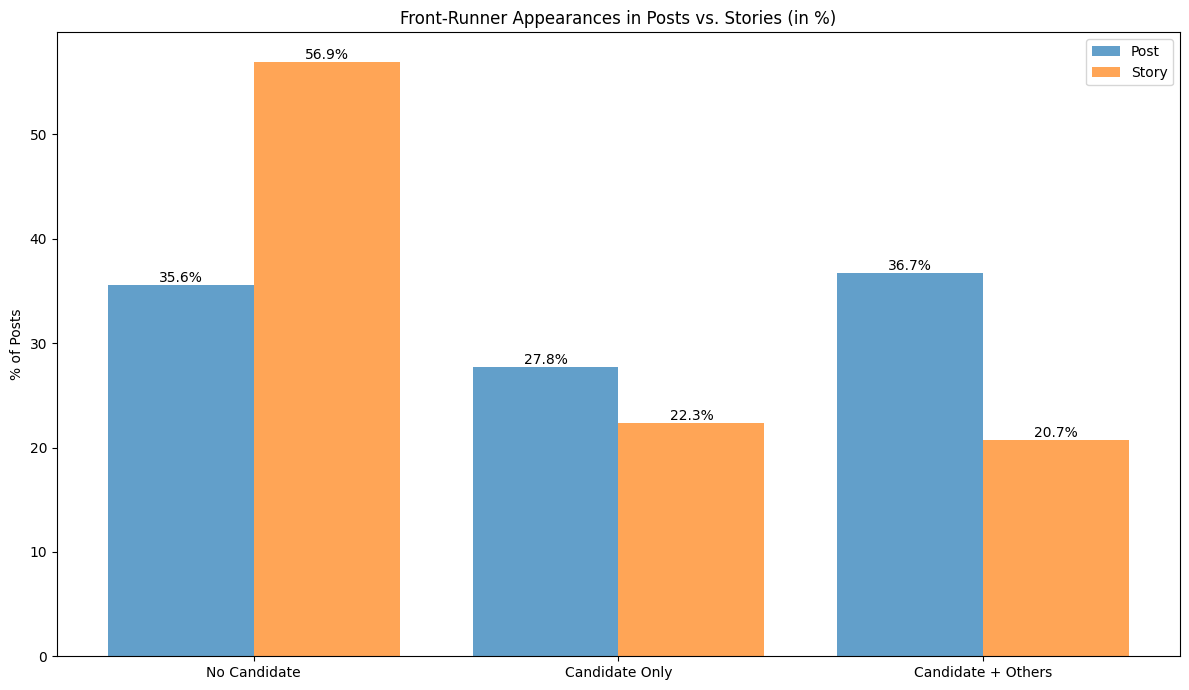

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, post_type):
    df_filtered = df[df['Post Type'] == post_type]
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }
    total = sum(counts.values())
    percentages_dict = {label: (count / total * 100) if total > 0 else 0 for label, count in counts.items()}
    return counts, percentages_dict

# Get counts for 'Post' type
post_counts, post_percentages = get_lengths_and_labels(combined_df, "Post")
# Get counts for 'Story' type
story_counts, story_percentages = get_lengths_and_labels(combined_df, "Story")

# Create contingency table
contingency_table = pd.DataFrame({
    'No Candidate': [post_counts['No Candidate'], story_counts['No Candidate']],
    'Candidate Only': [post_counts['Candidate Only'], story_counts['Candidate Only']],
    'Candidate + Others': [post_counts['Candidate + Others'], story_counts['Candidate + Others']]
}, index=['Post', 'Story'])

# Perform Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print the results
print(f"Chi-squared: {chi2}, p-value: {p}")

# After performing the chi-squared test
n = contingency_table.values.sum()  # Total number of observations
k = contingency_table.shape[1]       # Number of columns
r = contingency_table.shape[0]       # Number of rows

# Calculate Cramer's V
cramers_v = np.sqrt(chi2 / (n * min(k - 1, r - 1)))

# Print the Cramer's V result
print(f"Cramer's V: {cramers_v}")

# Continue with plotting (if not already done)


# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))
positions = range(len(post_percentages))

# Plotting the bars for Post
bars_post = ax.bar(positions, post_percentages.values(), width=0.4, label='Post', alpha=0.7)
# Plotting the bars for Story with offset
bars_story = ax.bar([p + 0.4 for p in positions], story_percentages.values(), width=0.4, label='Story', alpha=0.7)

# Add percentage labels on top of the bars
for bar in bars_post + bars_story:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

# Set labels and title
ax.set_ylabel('% of Posts')
ax.set_title('Front-Runner Appearances in Posts vs. Stories (in %)')
ax.set_xticks([p + 0.2 for p in positions])
ax.set_xticklabels(post_percentages.keys())
ax.legend()

# Adjust layout to avoid overlap and enhance readability
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
from statsmodels.stats.multitest import multipletests

# Function to calculate lengths and labels for a given type and party
def get_lengths_and_labels(df, post_type, party):
    df_filtered = df[(df['Post Type'] == post_type) & (df['party'] == party)]
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }
    total = sum(counts.values())
    percentages_dict = {label: (count / total * 100) if total > 0 else 0 for label, count in counts.items()}
    return counts, percentages_dict

# Get unique parties
unique_parties = combined_df['party'].unique()

# Prepare to collect results
results = []
p_values = []  # To store p-values for correction

# Define significance level
alpha = 0.05

# Loop through each party and perform analysis
for party in unique_parties:
    post_counts, post_percentages = get_lengths_and_labels(combined_df, "Post", party)
    story_counts, story_percentages = get_lengths_and_labels(combined_df, "Story", party)

    # Create contingency table
    contingency_table = pd.DataFrame({
        'No Candidate': [post_counts['No Candidate'], story_counts['No Candidate']],
        'Candidate Only': [post_counts['Candidate Only'], story_counts['Candidate Only']],
        'Candidate + Others': [post_counts['Candidate + Others'], story_counts['Candidate + Others']]
    }, index=['Post', 'Story'])

    # Perform Chi-squared test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Store p-value for correction later
    p_values.append(p)

    # Check if the chi-square requirements are met
    meets_requirements = all(expected.flatten() >= 5)

    # Calculate Cramer's V
    n = contingency_table.values.sum()  # Total number of observations
    k = contingency_table.shape[1]       # Number of columns
    r = contingency_table.shape[0]       # Number of rows
    cramers_v = np.sqrt(chi2 / (n * min(k - 1, r - 1)))

    # Store preliminary results without correction
    results.append({
        'Party': party,
        'Chi-squared': chi2,
        'p-value': p,
        'Cramer\'s V': cramers_v,
        'Meets Requirements': meets_requirements
    })

# Apply Bonferroni correction to p-values
corrected_p_values = multipletests(p_values, alpha=alpha, method='bonferroni')[1]

# Update significance and add to results
for i, p_corr in enumerate(corrected_p_values):
    if p_corr < 0.001:
        significance = "***"
    elif p_corr < 0.01:
        significance = "**"
    elif p_corr < 0.05:
        significance = "*"
    else:
        significance = ""

    results[i]['Corrected p-value'] = p_corr
    results[i]['Significant (Corrected)'] = significance

# Create results DataFrame
results_df = pd.DataFrame(results)

In [ ]:
print(results_df.to_markdown())

|    | Party         |   Chi-squared |     p-value |   Cramer's V | Meets Requirements   |   Corrected p-value | Significant (Corrected)   |
|---:|:--------------|--------------:|------------:|-------------:|:---------------------|--------------------:|:--------------------------|
|  0 | B90DieGruenen |       8.79362 | 0.0123166   |     0.13979  | True                 |         0.0615829   |                           |
|  1 | CDU           |      53.9679  | 1.90997e-12 |     0.283389 | True                 |         9.54986e-12 | ***                       |
|  2 | FDP           |       9.65498 | 0.00800658  |     0.219168 | True                 |         0.0400329   | *                         |
|  3 | CSU           |      19.5033  | 5.81983e-05 |     0.223055 | True                 |         0.000290992 | ***                       |
|  4 | SPD           |      17.5627  | 0.000153567 |     0.206969 | True                 |         0.000767836 | ***                       |


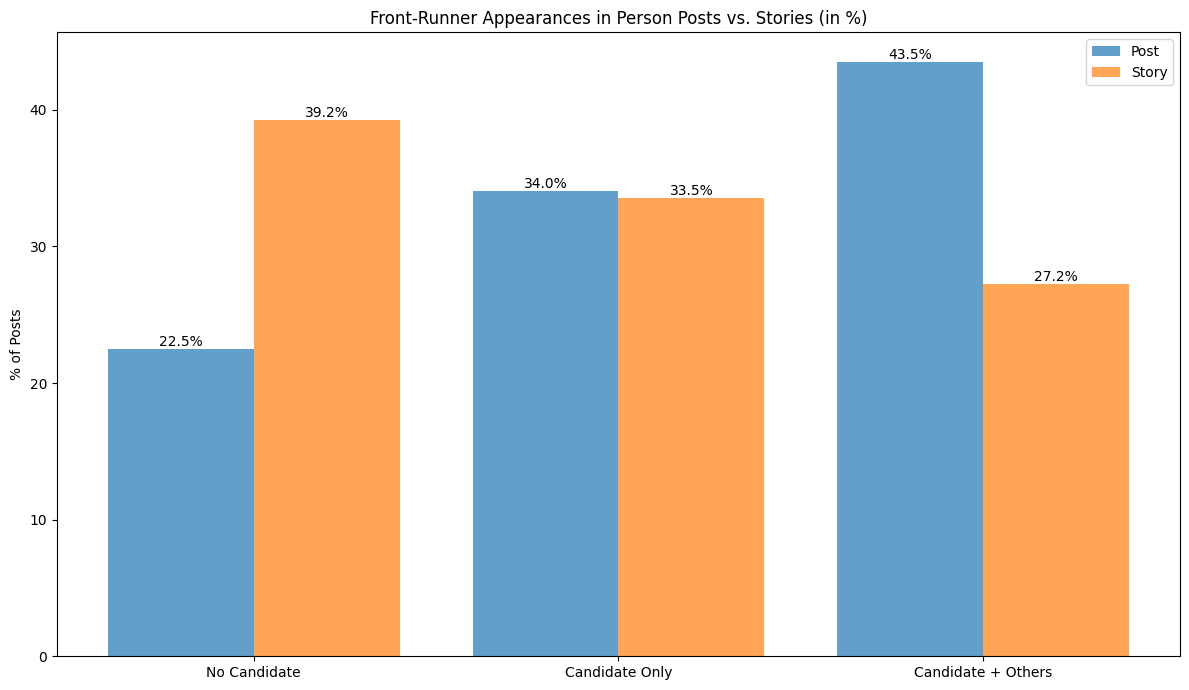

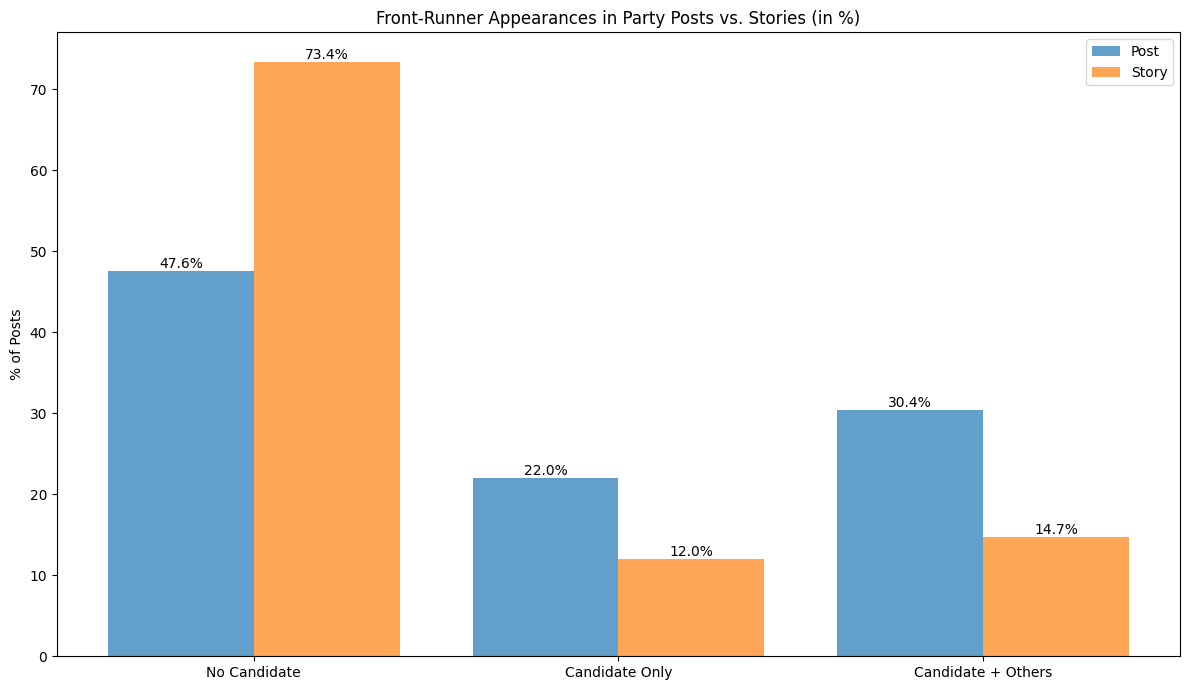

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

# Function to calculate lengths and labels for a given type
def get_lengths_and_labels(df, post_type, entity_type):
    df_filtered = df[(df['Post Type'] == post_type) & (df['type'] == entity_type)]
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }
    total = sum(counts.values())
    percentages_dict = {label: (count / total * 100) if total > 0 else 0 for label, count in counts.items()}
    return counts, percentages_dict

# Types to analyze
types = ['Person', 'Party']

# Prepare to collect results
results = []

# Loop through each entity type
for entity_type in types:
    post_counts, post_percentages = get_lengths_and_labels(combined_df, "Post", entity_type)
    story_counts, story_percentages = get_lengths_and_labels(combined_df, "Story", entity_type)

    # Create contingency table
    contingency_table = pd.DataFrame({
        'No Candidate': [post_counts['No Candidate'], story_counts['No Candidate']],
        'Candidate Only': [post_counts['Candidate Only'], story_counts['Candidate Only']],
        'Candidate + Others': [post_counts['Candidate + Others'], story_counts['Candidate + Others']]
    }, index=['Post', 'Story'])

    # Perform Chi-squared test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Check if the chi-square requirements are met
    meets_requirements = np.all(expected >= 5)

    # Calculate Cramer's V
    n = contingency_table.values.sum()  # Total number of observations
    k = contingency_table.shape[1]       # Number of columns
    r = contingency_table.shape[0]       # Number of rows
    cramers_v = np.sqrt(chi2 / (n * min(k - 1, r - 1)))

    # Determine significance level
    significance = ""
    if p < 0.001:
        significance = "***"
    elif p < 0.01:
        significance = "**"
    elif p < 0.05:
        significance = "*"

    # Store results
    results.append({
        'Type': entity_type,
        'Chi-squared': chi2,
        'p-value': p,
        'Cramer\'s V': cramers_v,
        'Significant': significance,
        'Meets Requirements': meets_requirements
    })

    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 7))
    positions = range(len(post_percentages))

    # Plotting the bars for Post
    bars_post = ax.bar(positions, post_percentages.values(), width=0.4, label='Post', alpha=0.7)
    # Plotting the bars for Story with offset
    bars_story = ax.bar([p + 0.4 for p in positions], story_percentages.values(), width=0.4, label='Story', alpha=0.7)

    # Add percentage labels on top of the bars
    for bar in bars_post + bars_story:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

    # Set labels and title
    ax.set_ylabel('% of Posts')
    ax.set_title(f'Front-Runner Appearances in {entity_type} Posts vs. Stories (in %)')
    ax.set_xticks([p + 0.2 for p in positions])
    ax.set_xticklabels(post_percentages.keys())
    ax.legend()

    # Adjust layout to avoid overlap and enhance readability
    plt.tight_layout()
    plt.show()

# Create results DataFrame
results_df = pd.DataFrame(results)


Unterschiede Story vs. Posts innerhalb der Kategorien Party bzw. Person

In [ ]:
print(results_df.to_markdown())

|    | Type   |   Chi-squared |     p-value |   Cramer's V | Significant   | Meets Requirements   |
|---:|:-------|--------------:|------------:|-------------:|:--------------|:---------------------|
|  0 | Person |       37.1774 | 8.45325e-09 |     0.190821 | ***           | True                 |
|  1 | Party  |       72.0278 | 2.28755e-16 |     0.255426 | ***           | True                 |


Jetzt wollen wir noch den Unterschied Story vs. Posts für jede Partei

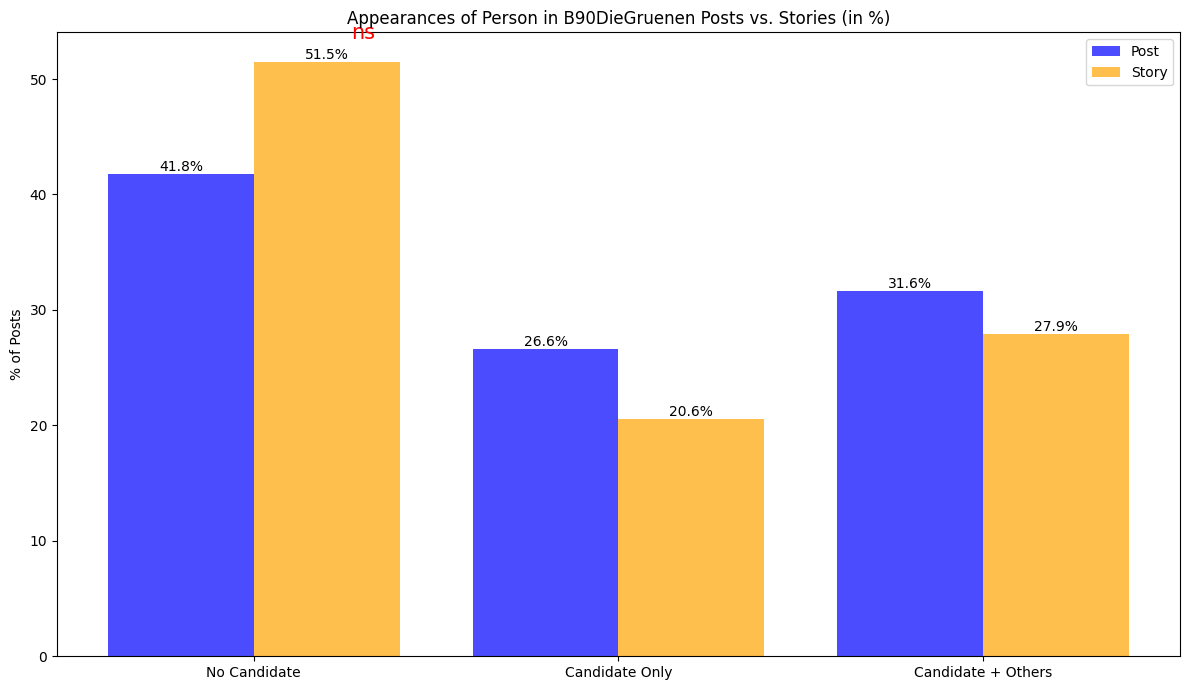

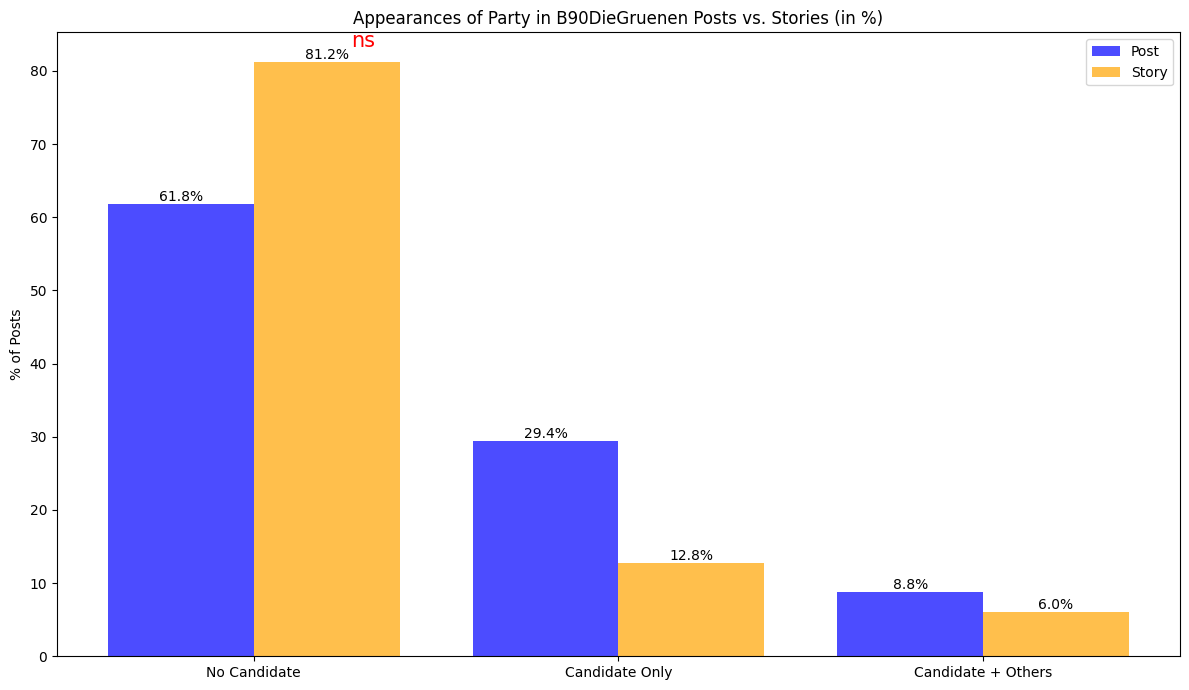

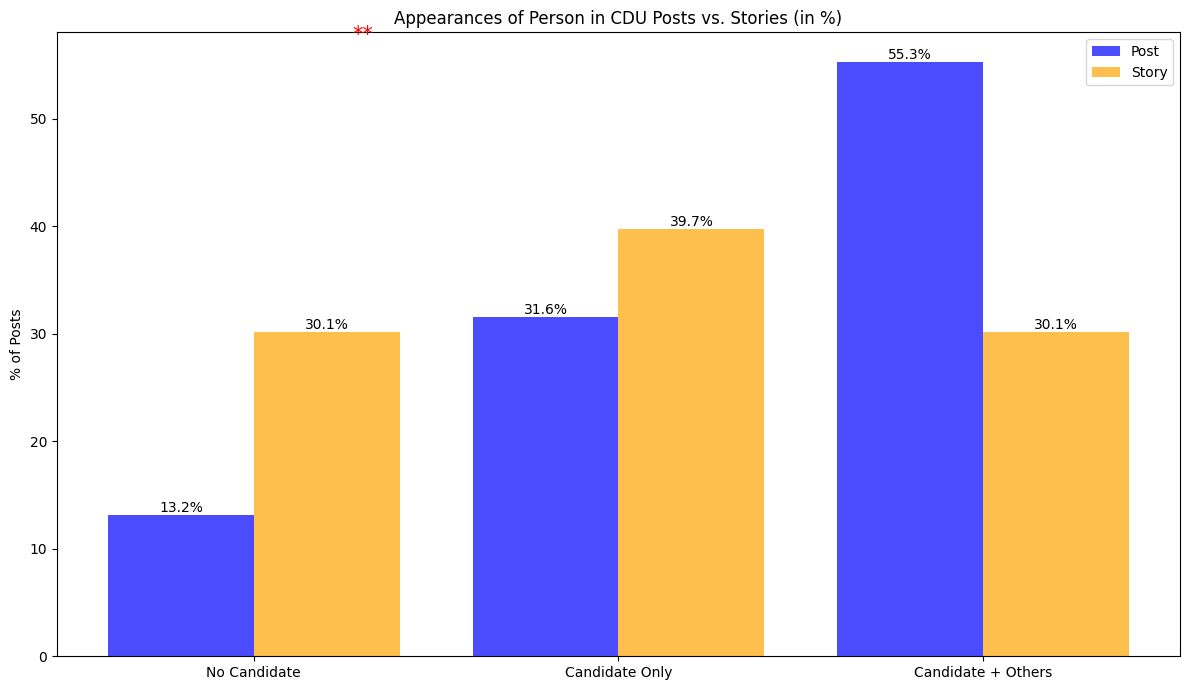

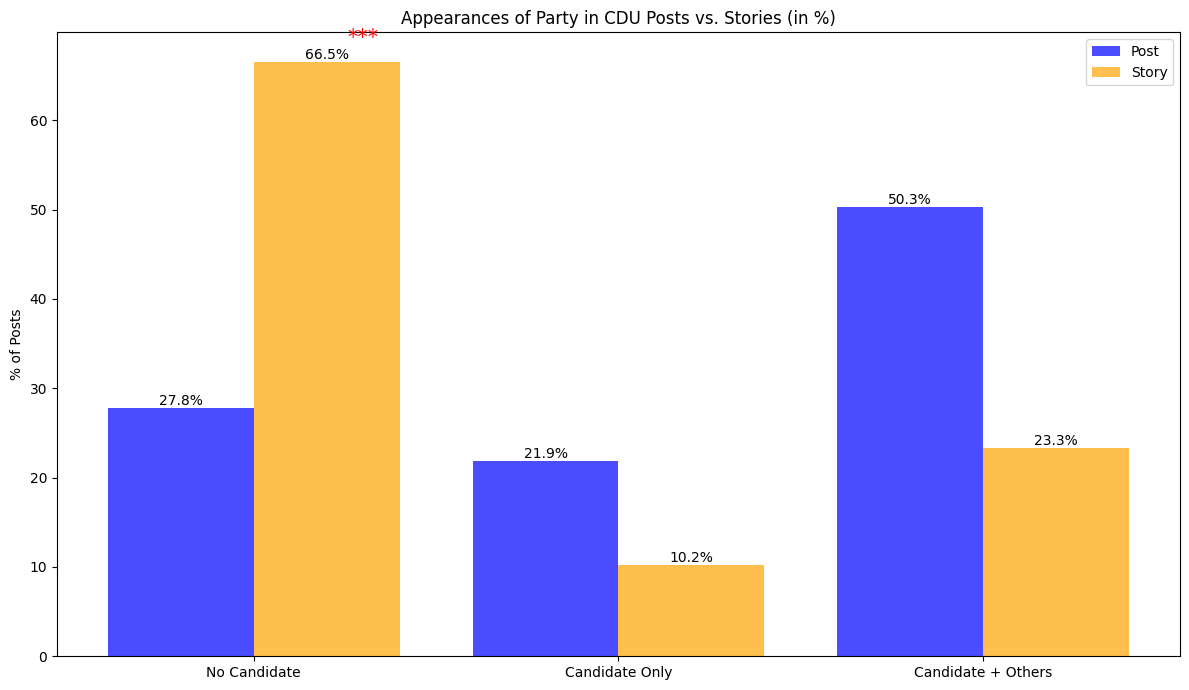

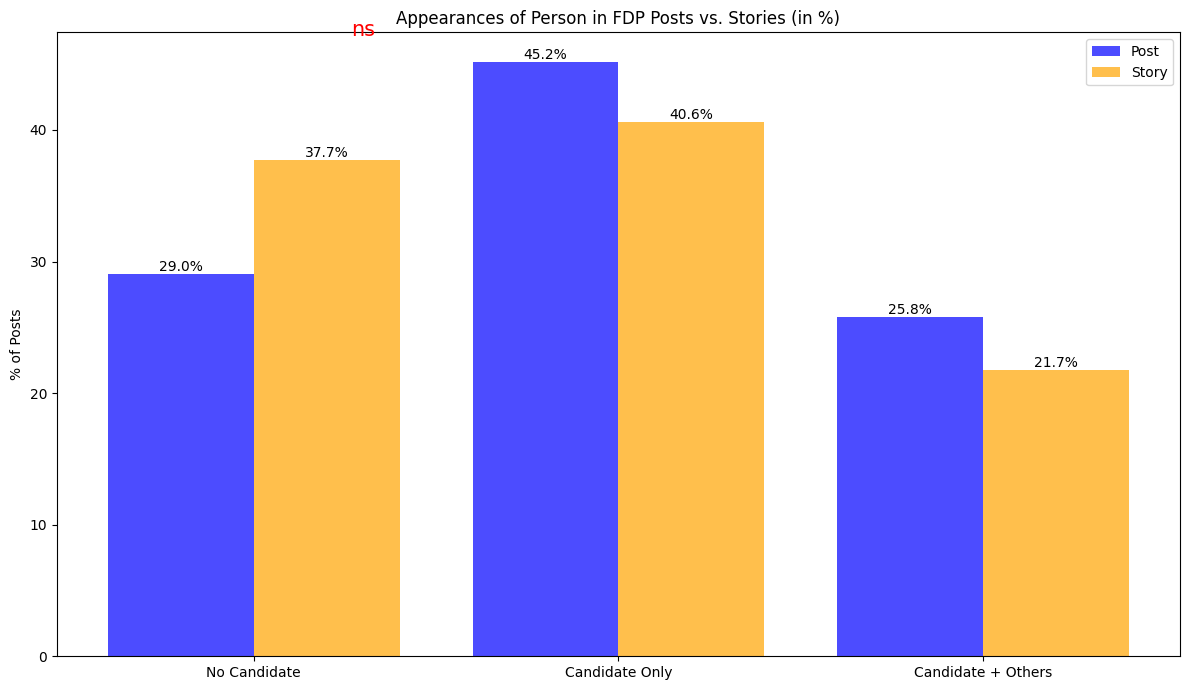

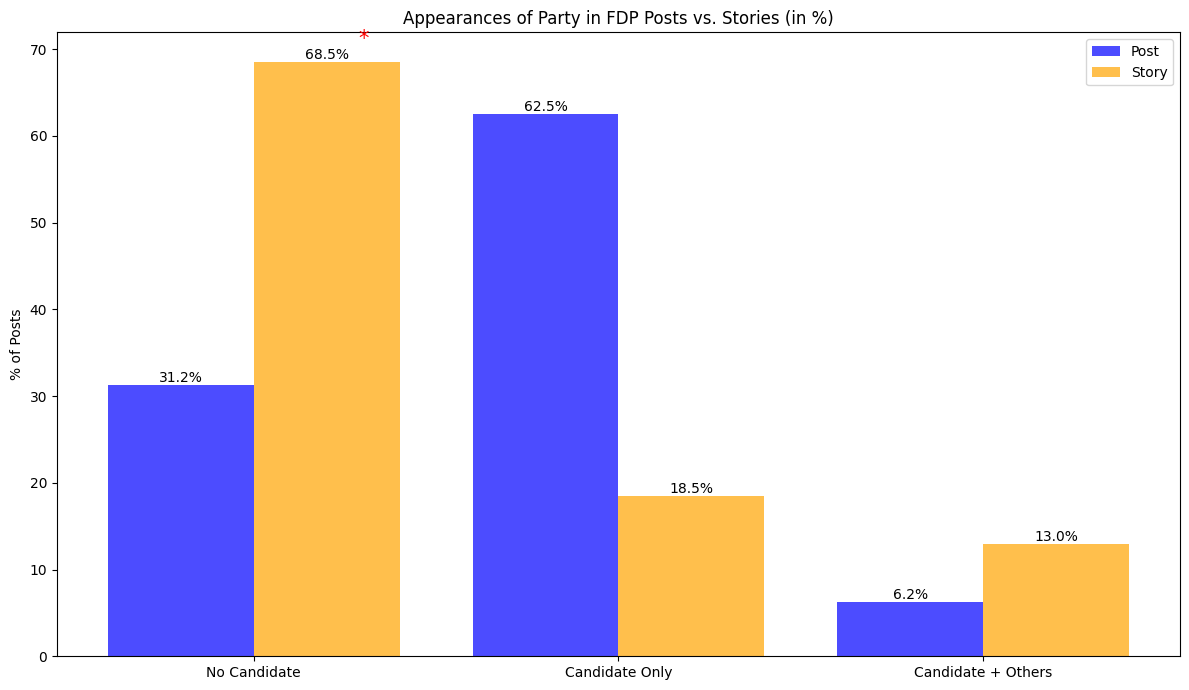

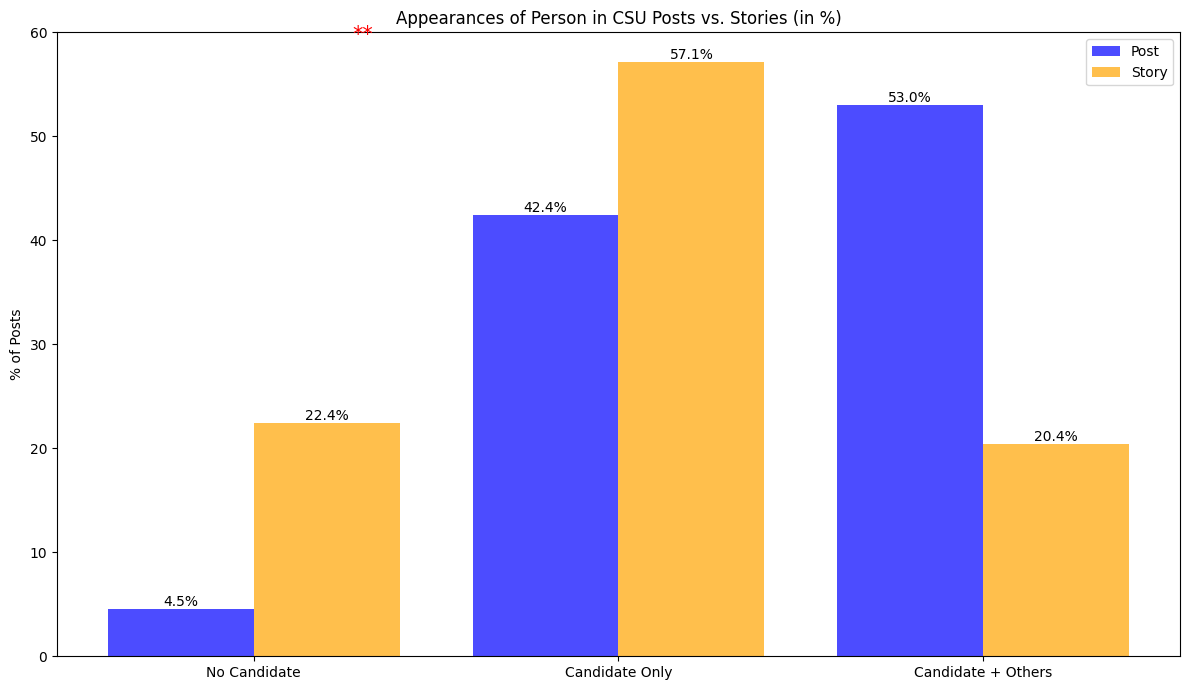

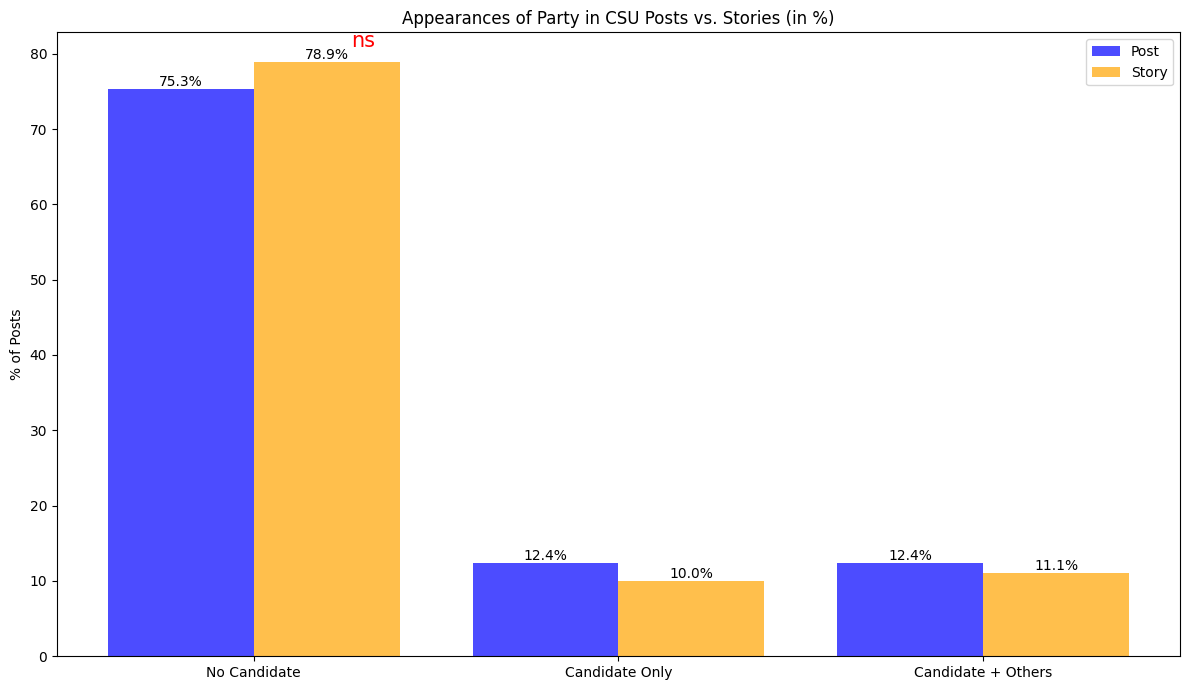

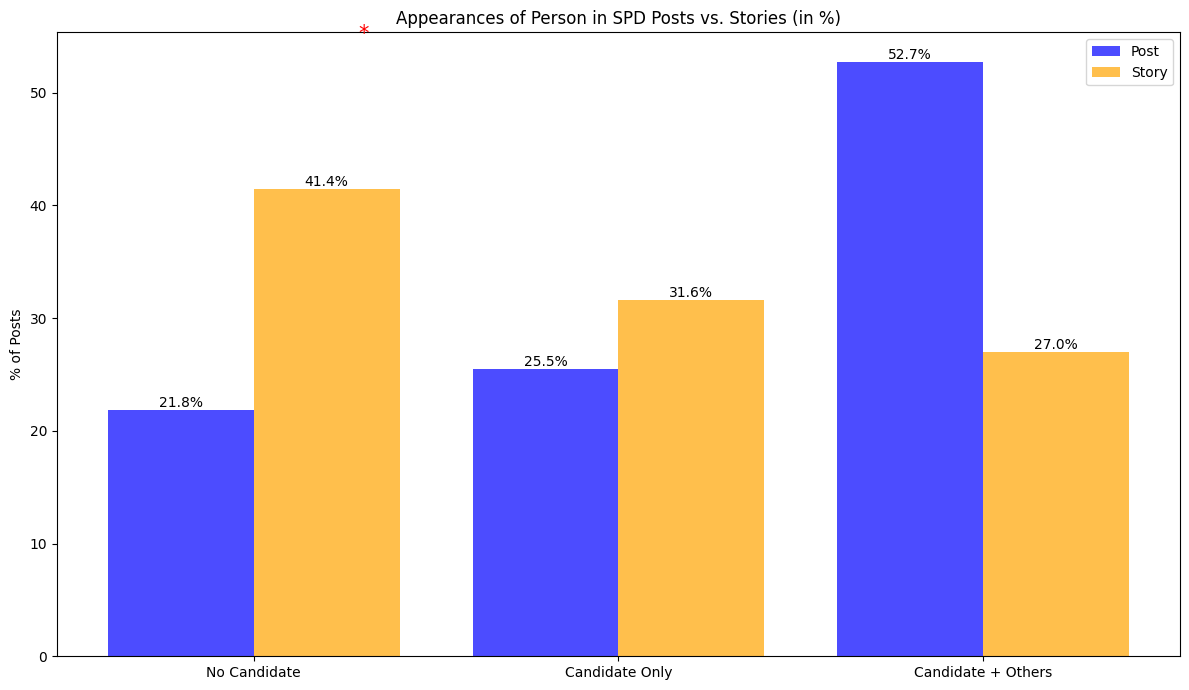

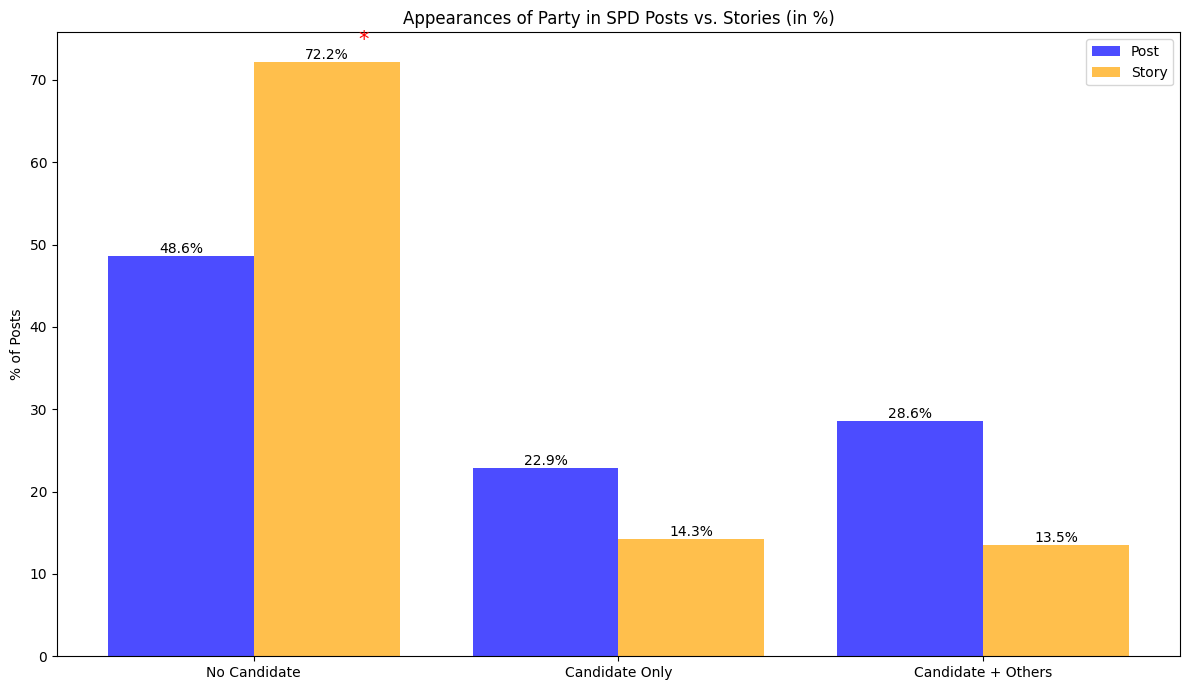

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
from statsmodels.stats.multitest import multipletests

# Fill NaN values in the 'Names' column with "None"
combined_df['Names'] = combined_df['Names'].fillna("None")

# Function to calculate lengths and labels for a given party and post type
def get_lengths_and_labels(df, post_type, party, candidate_type):
    df_filtered = df[(df['Post Type'] == post_type) & (df['party'] == party) & (df['type'] == candidate_type)]
    counts = {
        'No Candidate': len(df_filtered[df_filtered['Names'] == "None"]),
        'Candidate Only': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] == "1")]),
        'Candidate + Others': len(df_filtered[(df_filtered['Names'] != "None") & (df_filtered['GPT Count'] != "0") & (df_filtered['GPT Count'] != "1")])
    }
    total = sum(counts.values())
    percentages_dict = {label: (count / total * 100) if total > 0 else 0 for label, count in counts.items()}
    return counts, percentages_dict

# Get unique parties and types
unique_parties = combined_df['party'].unique()
unique_types = combined_df['type'].unique()

# Prepare to collect results and p-values for correction
results = []
p_values = []

# Loop through each party and candidate type
for party in unique_parties:
    for candidate_type in unique_types:
        post_counts, post_percentages = get_lengths_and_labels(combined_df, "Post", party, candidate_type)
        story_counts, story_percentages = get_lengths_and_labels(combined_df, "Story", party, candidate_type)

        # Create contingency table
        contingency_table = pd.DataFrame({
            'No Candidate': [post_counts['No Candidate'], story_counts['No Candidate']],
            'Candidate Only': [post_counts['Candidate Only'], story_counts['Candidate Only']],
            'Candidate + Others': [post_counts['Candidate + Others'], story_counts['Candidate + Others']]
        }, index=['Post', 'Story'])

        # Perform Chi-squared test
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        # Store the p-value for Bonferroni correction later
        p_values.append(p)

        # Calculate Cramér's V
        n = contingency_table.values.sum()  # Total number of observations
        r, k = contingency_table.shape  # Number of rows and columns
        cramers_v = np.sqrt(chi2 / (n * (min(k - 1, r - 1) if min(k - 1, r - 1) > 0 else 1)))

        # Check chi-squared test requirements
        meets_requirements = np.all(expected >= 5)

        # Store results without corrected significance for now
        results.append({
            'Party': party,
            'Type': candidate_type,
            'Chi-squared': chi2,
            'p-value': p,
            'Cramér\'s V': cramers_v,
            'Significant': "",
            'Meets Chi-squared Requirements': "Yes" if meets_requirements else "No"
        })

# Apply Bonferroni correction to the collected p-values
corrected_p_values = multipletests(p_values, alpha=0.05, method='bonferroni')[1]

# Update significance and store corrected p-values
for i, p_corr in enumerate(corrected_p_values):
    if p_corr < 0.001:
        significance_level = "***"
    elif p_corr < 0.01:
        significance_level = "**"
    elif p_corr < 0.05:
        significance_level = "*"
    else:
        significance_level = "ns"  # Not significant

    results[i]['Corrected p-value'] = p_corr
    results[i]['Significant (Corrected)'] = significance_level

    # Create the plot for each party and candidate type
    party = results[i]['Party']
    candidate_type = results[i]['Type']
    post_percentages = get_lengths_and_labels(combined_df, "Post", party, candidate_type)[1]
    story_percentages = get_lengths_and_labels(combined_df, "Story", party, candidate_type)[1]

    fig, ax = plt.subplots(figsize=(12, 7))
    positions = range(len(post_percentages))

    # Plotting the bars for Post
    bars_post = ax.bar(positions, post_percentages.values(), width=0.4, label='Post', alpha=0.7, color='blue')
    # Plotting the bars for Story with offset
    bars_story = ax.bar([p + 0.4 for p in positions], story_percentages.values(), width=0.4, label='Story', alpha=0.7, color='orange')

    # Add percentage labels on top of the bars
    for bar in bars_post + bars_story:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

    # Significance annotation
    max_height = max(list(post_percentages.values()) + list(story_percentages.values())) + 2
    ax.annotate(significance_level, xy=(0.5, max_height), ha='center', fontsize=15, color='red')

    # Set labels and title
    ax.set_ylabel('% of Posts')
    ax.set_title(f'Appearances of {candidate_type} in {party} Posts vs. Stories (in %)')
    ax.set_xticks([p + 0.2 for p in positions])
    ax.set_xticklabels(post_percentages.keys())
    ax.legend()

    # Adjust layout to avoid overlap and enhance readability
    plt.tight_layout()
    plt.show()

# Print results for all parties and types
results_df = pd.DataFrame(results)

In [ ]:
print(results_df.to_markdown())

|    | Party         | Type   |   Chi-squared |     p-value |   Cramér's V | Significant   | Meets Chi-squared Requirements   |   Corrected p-value | Significant (Corrected)   |
|---:|:--------------|:-------|--------------:|------------:|-------------:|:--------------|:---------------------------------|--------------------:|:--------------------------|
|  0 | B90DieGruenen | Person |       2.28724 | 0.318664    |    0.0899006 |               | Yes                              |         1           | ns                        |
|  1 | B90DieGruenen | Party  |       6.28048 | 0.0432724   |    0.193927  |               | No                               |         0.432724    | ns                        |
|  2 | CDU           | Person |      16.8053  | 0.00022427  |    0.242829  |               | Yes                              |         0.0022427   | **                        |
|  3 | CDU           | Party  |      55.2403  | 1.01091e-12 |    0.377809  |               | Yes              